# Statistical Plots & Distribution Analysis

## Dataset Used
Sales Dataset

## Objective
The main objective of this project is to analyze the distribution of sales data using statistical visualization techniques.

### Techniques Used
- Histogram
- KDE Plot
- Boxplot
- Distribution Comparison
- Outlier Detection
- Skewness Analysis

### Libraries Used
- Pandas
- NumPy
- Matplotlib
- Seaborn

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Style Setting
sns.set_style("whitegrid")

# Figure Size
plt.rcParams['figure.figsize'] = (10,6)

In [9]:
# Load Dataset
df = pd.read_csv("C:/Users/iamhe/Downloads/sales_data.csv")
df

,Order_ID,Customer_Name,Region,Category,Sales,Profit,Quantity
0,ORD1001,William Gonzalez,North,Electronics,4640.45,319.43,2
1,ORD1002,Brandon Lewis,South,Groceries,5502.87,1088.33,5
2,ORD1003,Donna Schwartz,East,Furniture,4349.57,1145.32,7
3,ORD1004,Patrick Marshall,South,Clothing,6164.21,647.87,9
4,ORD1005,Kristy Larson,South,Groceries,5683.73,908.75,5
...,...,...,...,...,...,...,...
495,ORD1496,Lori Lee,South,Clothing,5965.76,906.47,12
496,ORD1497,Christopher Khan,West,Electronics,3780.04,462.93,5
497,ORD1498,Kelly Thompson,West,Furniture,3548.45,891.64,14
498,ORD1499,Robert Trevino,South,Electronics,3271.72,687.46,1


In [10]:
print("Shape of Dataset :", df.shape)

print("\nColumn Names:\n")
print(df.columns)

print("\nData Types:\n")
print(df.dtypes)

Shape of Dataset : (500, 7)

Column Names:

Index(['Order_ID', 'Customer_Name', 'Region', 'Category', 'Sales', 'Profit',
       'Quantity'],
      dtype='object')

Data Types:

Order_ID          object
Customer_Name     object
Region            object
Category          object
Sales            float64
Profit           float64
Quantity           int64
dtype: object


In [11]:
# Missing Values
df.isnull().sum()

Order_ID         0
Customer_Name    0
Region           0
Category         0
Sales            0
Profit           0
Quantity         0
dtype: int64

In [12]:
# Statistical Summary
df.describe()

,Sales,Profit,Quantity
count,500.000000,500.000000,500.000000
mean,5007.129600,882.352740,8.014000
std,1838.082933,518.613163,4.295428
min,200.000000,17.810000,1.000000
25%,3851.972500,470.182500,4.000000
50%,4985.090000,785.630000,8.000000
75%,6230.420000,1212.177500,12.000000
max,10895.470000,3136.210000,15.000000


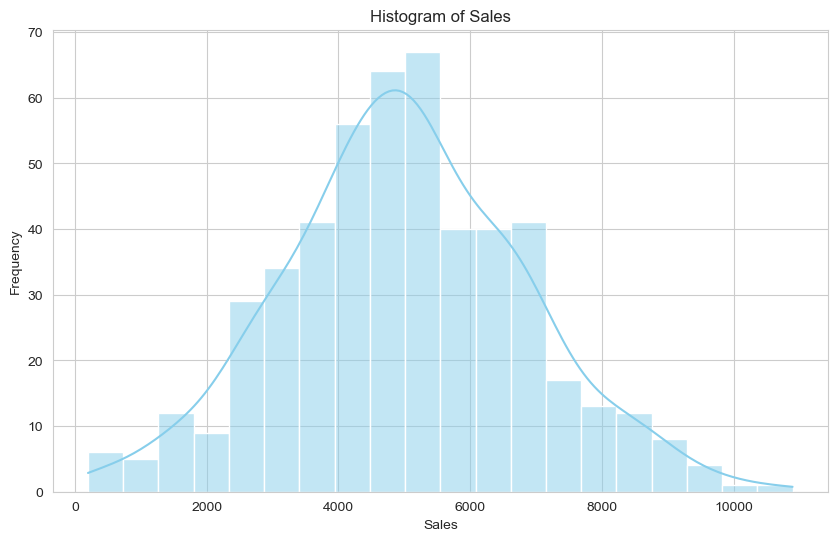

In [13]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x='Sales',
    bins=20,
    kde=True,
    color='skyblue'
)

plt.title("Histogram of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show()

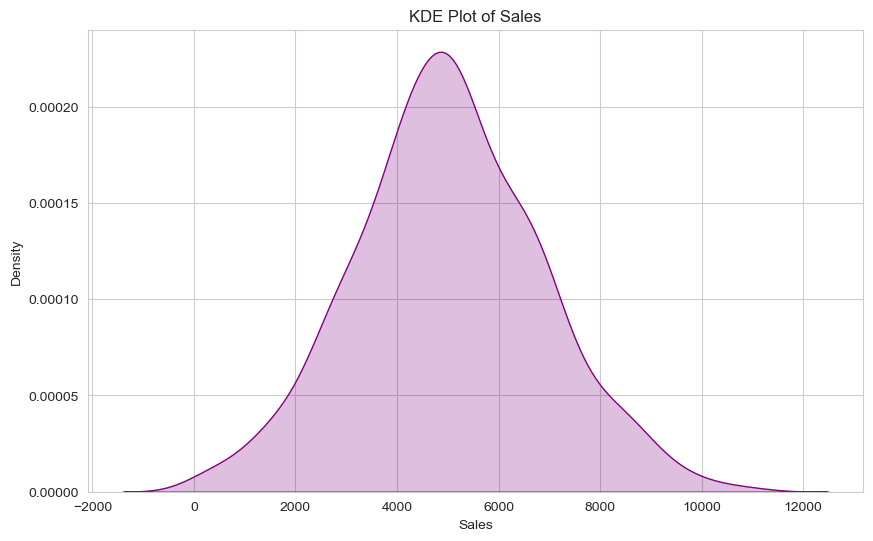

In [14]:
plt.figure(figsize=(10,6))

sns.kdeplot(
    data=df,
    x='Sales',
    fill=True,
    color='purple'
)

plt.title("KDE Plot of Sales")
plt.xlabel("Sales")
plt.ylabel("Density")

plt.show()

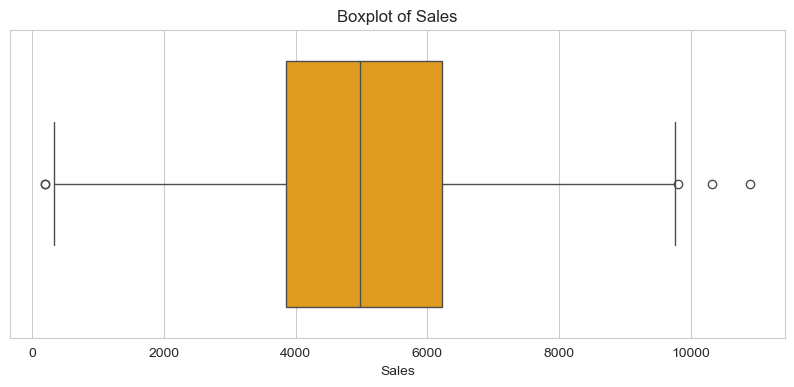

In [15]:
plt.figure(figsize=(10,4))

sns.boxplot(
    x=df['Sales'],
    color='orange'
)

plt.title("Boxplot of Sales")

plt.show()

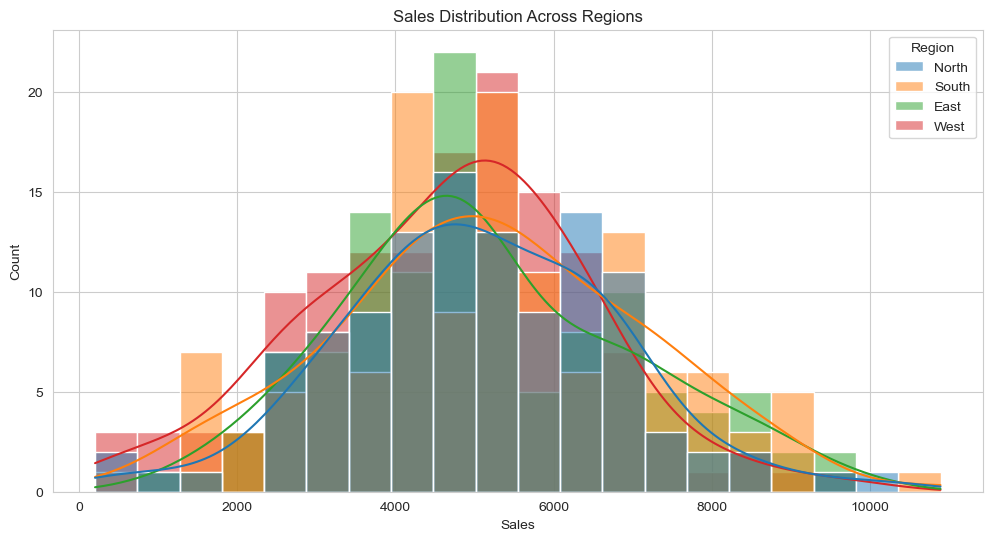

In [16]:
plt.figure(figsize=(12,6))

sns.histplot(
    data=df,
    x='Sales',
    hue='Region',
    kde=True,
    bins=20
)

plt.title("Sales Distribution Across Regions")

plt.show()

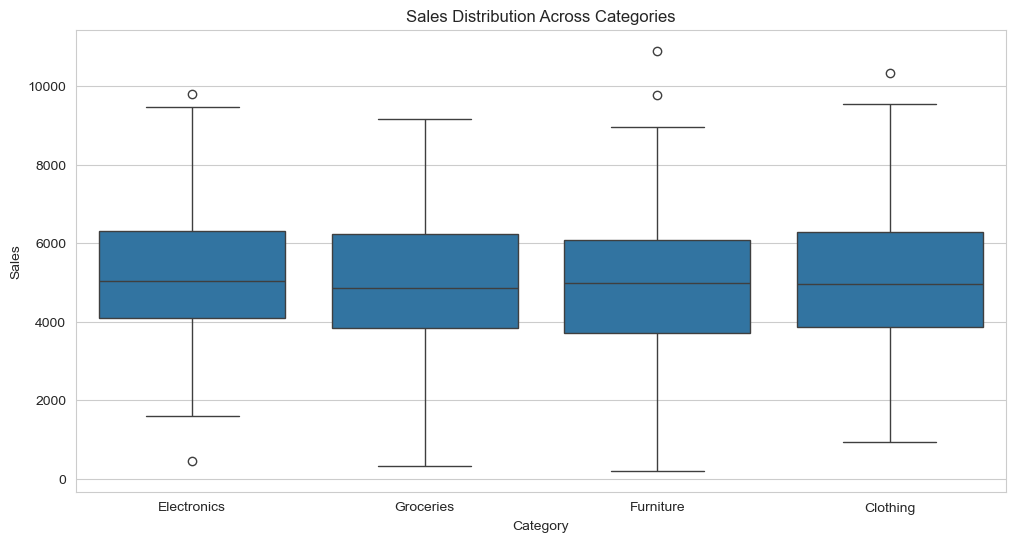

In [17]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x='Category',
    y='Sales'
)

plt.title("Sales Distribution Across Categories")

plt.show()

In [18]:
# Calculate Skewness
skewness_value = df['Sales'].skew()

print("Skewness Value :", round(skewness_value,2))

if skewness_value > 0:
    print("The distribution is Positively Skewed")

elif skewness_value < 0:
    print("The distribution is Negatively Skewed")

else:
    print("The distribution is Symmetric")

Skewness Value : 0.1
The distribution is Positively Skewed


In [19]:
mean_value = df['Sales'].mean()
median_value = df['Sales'].median()

print("Mean :", round(mean_value,2))
print("Median :", round(median_value,2))

if mean_value > median_value:
    print("Positive Skewness Detected")

elif mean_value < median_value:
    print("Negative Skewness Detected")

else:
    print("Symmetric Distribution")

Mean : 5007.13
Median : 4985.09
Positive Skewness Detected


In [20]:
Q1 = df['Sales'].quantile(0.25)
Q3 = df['Sales'].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outliers = df[
    (df['Sales'] < lower_limit) |
    (df['Sales'] > upper_limit)
]

print("Lower Limit :", round(lower_limit,2))
print("Upper Limit :", round(upper_limit,2))

print("\nTotal Outliers :", len(outliers))

outliers.head()

Lower Limit : 284.3
Upper Limit : 9798.09

Total Outliers : 5


,Order_ID,Customer_Name,Region,Category,Sales,Profit,Quantity
39,ORD1040,Alexander Maldonado,South,Furniture,200.00,20.13,3
159,ORD1160,Timothy Ortega,West,Electronics,9801.66,2212.54,12
273,ORD1274,Katie Nguyen,North,Clothing,10322.70,710.40,3
403,ORD1404,Patricia Smith,South,Furniture,10895.47,3136.21,2
447,ORD1448,Vincent Cook,West,Furniture,200.00,18.27,11


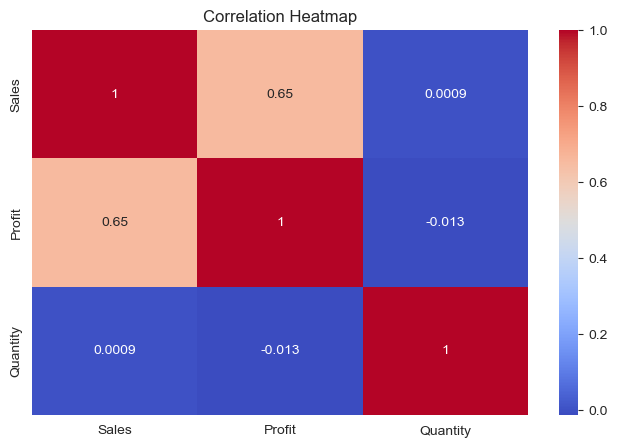

In [21]:
plt.figure(figsize=(8,5))

numeric_df = df[['Sales', 'Profit', 'Quantity']]

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

In [22]:
# Histogram
plt.figure(figsize=(10,6))

sns.histplot(df['Sales'], kde=True)

plt.title("Histogram of Sales")

plt.savefig("histogram_plot.png")

plt.close()


# KDE Plot
plt.figure(figsize=(10,6))

sns.kdeplot(df['Sales'], fill=True)

plt.title("KDE Plot of Sales")

plt.savefig("kde_plot.png")

plt.close()


# Boxplot
plt.figure(figsize=(10,4))

sns.boxplot(x=df['Sales'])

plt.title("Boxplot of Sales")

plt.savefig("boxplot.png")

plt.close()

print("Plots Saved Successfully")

Plots Saved Successfully


In [26]:
# Final Interpretation

The statistical analysis of the sales dataset provides useful insights into the overall distribution of sales values.

The histogram and KDE plot indicate that the majority of sales values are concentrated around the middle range, while a few observations extend toward higher sales values. The boxplot clearly identifies several outliers, representing unusually large sales transactions.

Distribution comparison across different regions and categories shows variation in sales performance among groups. The skewness analysis helps determine whether the data distribution is balanced or shifted toward one side.

The correlation heatmap reveals relationships among sales, profit, and quantity variables. Overall, this project demonstrates how statistical plots and distribution analysis help in understanding data behavior, spread, variability, and unusual patterns effectively.

SyntaxError: invalid syntax (2967981949.py, line 3)